# Layer Skipping Analysis on DINO

This notebook analyzes information flow between layers in a transformer model (e.g., DINO ViT) to identify redundant layers that can potentially be skipped without significantly affecting classification performance. The analysis includes similarity comparisons between layer representations (using CKA, CKNNA, cosine similarity) and a linear probing experiment to test the impact of removing selected layers.

In [127]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import Subset, DataLoader
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import pairwise_kernels

from PIL import Image
import timm
import os
import random

import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

### Reproducibility
To ensure consistent results across runs, we fix all random seeds. This guarantees that data sampling and model behavior are deterministic and reproducible.

In [16]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### Load and Filter ImageNet Subset

We load a subset of the ImageNet dataset from local folders and select images belonging to a single class. Images are transformed to match the input requirements of DINO models.

In [17]:
'''
Zestaw z kaggla, który wysłał Vladimir zawiera 100 klas i to jest podzielone na 4 foldery po 25 i 
zbiór walidacyjny ze wszystkiemi 100 klasami. Ja pobrałam i rozpakowałam w folderze data train.X1.zip i
val.X.zip. (początkowo chciałam wyrzucić te klasy, z val, których nie mamy, ale numery klas nie są po kolei i już
nie kombinowałam) Generalnie proponuje nie usuwać tych danych na razie, bo mogą sie jeszcze przydać.
'''

'\nZestaw z kaggla, który wysłał Vladimir zawiera 100 klas i to jest podzielone na 4 foldery po 25 i \nzbiór walidacyjny ze wszystkiemi 100 klasami. Ja pobrałam i rozpakowałam w folderze data train.X1.zip i\nval.X.zip. (początkowo chciałam wyrzucić te klasy, z val, których nie mamy, ale numery klas nie są po kolei i już\nnie kombinowałam) Generalnie proponuje nie usuwać tych danych na razie, bo mogą sie jeszcze przydać.\n'

In [51]:
train_path = "../data/train.X1"
val_path = "../data/val.X"

transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)

classes = train_dataset.classes  

selected_class = classes[0]
print("Selected class:", selected_class)

class_idx = train_dataset.class_to_idx[selected_class]

def get_class_subset(dataset, class_idx):
    indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]
    return Subset(dataset, indices)

train_subset = get_class_subset(train_dataset, class_idx)
val_subset = get_class_subset(val_dataset, class_idx)

train_loader = DataLoader(train_subset, batch_size=8, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False)

Selected class: n01440764


In [ ]:
def extract_layer_outputs(model, x):
    '''
    Extracts intermediate layer outputs from a ViT model during a forward pass.
    '''
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    hooks = [blk.register_forward_hook(hook_fn) for blk in model.blocks]

    with torch.no_grad():
        _ = model(x)

    for hook in hooks:
        hook.remove()

    return activations


def compute_logits_from_layers(model, layer_outputs):
    '''
    Computes classification logits from intermediate layer representations using the model's head.
    '''
    cls_tokens = [output[:, 0] for output in layer_outputs]  # CLS token
    head = model.head
    logits = [head(F.normalize(cls, dim=-1)) for cls in cls_tokens]
    return logits


def collect_logits_from_batches(model, dataloader, max_batches=None):
    '''
    Collects logits from all transformer layers for multiple batches of data.
    '''
    all_logits = []

    for batch_idx, (x_batch, _) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_batch = x_batch.to(next(model.parameters()).device)
        layer_outputs = extract_layer_outputs(model, x_batch)
        logits = compute_logits_from_layers(model, layer_outputs)
        all_logits.append(logits)

    return all_logits

### Similarity Metrics Between Layer Representations
To investigate the flow and redundancy of information across layers in the ViT model, we apply the following similarity measures between layer-wise representations:

1. Cosine Similarity Matrix

Cosine similarity measures the angle between two vectors, indicating their directional alignment regardless of magnitude. For each pair of layers, we compute cosine similarity between their logits (normalized [CLS] tokens passed through the model head), averaged across the batch:

$$\text{similarity}(x, y) = \frac{x \cdot y}{||x|| \cdot ||y||}$$
 
Interpretation:

* Values close to 1 indicate highly similar representations.
* Values around 0 suggest orthogonality (no similarity).
* Values below 0 (rare but possible) indicate opposing directions in feature space.

In [144]:
def compute_cosine_similarity_matrix(logits):
    L = len(logits)
    sims = torch.zeros(L, L)
    for i in range(L):
        for j in range(L):
            sims[i, j] = F.cosine_similarity(
                logits[i], logits[j], dim=-1
            ).mean()
    return sims.numpy()

2. Linear CKA (Centered Kernel Alignment)

Description:
CKA measures the similarity between two sets of representations, invariant to orthogonal transformations and isotropic scaling. It is more robust than cosine similarity for high-dimensional data.

CKA is calculated using the normalized Hilbert-Schmidt Independence Criterion (HSIC) between representations X and Y:

$$\text{CKA}(X, Y) = \frac{||XY^T||^2}{||XX^T|| \cdot ||YY^T|| + \epsilon} $$

Interpretation:

* Values range from 0 (no similarity) to 1 (perfect similarity).
* High values suggest that two layers encode similar information.

In [145]:
def compute_linear_CKA(X, Y):
    X = X - X.mean(0)
    Y = Y - Y.mean(0)

    hsic = (X @ Y.T).norm() ** 2
    var1 = (X @ X.T).norm()
    var2 = (Y @ Y.T).norm()

    return hsic / (var1 * var2 + 1e-5)

def compute_cka_matrix(logits):
    L = len(logits)
    matrix = torch.zeros(L, L)
    for i in range(L):
        for j in range(L):
            matrix[i, j] = compute_linear_CKA(
                logits[i].cpu(), logits[j].cpu()
            )
    return matrix.numpy()


3. Centered Kernel Normalized Nearest Neighbors Agreement (CKNNA)

CKNNA is a similarity metric designed to evaluate the consistency of local neighborhoods between different layers' representations in a neural network.

How it works:
1. For each set of representations (e.g., from different layers), it computes an RBF kernel matrix.
2. The kernel matrices are centered (similar to the preprocessing used in CKA).
3. For each sample, it finds its top-𝑘 nearest neighbors in the kernel space for both representation sets.
4. It computes the proportion of shared neighbors across both kernel spaces for all samples.


- Let $K_X$ and $K_Y$ be centered RBF kernels for X and Y.
- For each sample i, let $N_k^X(i)$ and $N_k^Y(i)$ be its top-𝑘 neighbors in $K_X$ and $K_Y$, respectively.
- The CKNNA score is:

$$
\text{CKNNA}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} \frac{|N_k^X(i) \cap N_k^Y(i)|}{k}
$$

Interpretation:
* Values close to **1** indicate that the neighborhood structure is preserved between the two layers in kernel space.
* Values close to **0** indicate dissimilar neighborhood structures, suggesting information drift or change in local geometry.

In [146]:
def center_kernel(K):
    """Centering the kernel matrix (K -> HKH)"""
    n = K.shape[0]
    unit = np.ones((n, n)) / n
    return K - unit @ K - K @ unit + unit @ K @ unit


def rbf_kernel(X, gamma=None):
    """Compute RBF (Gaussian) kernel"""
    return pairwise_kernels(X, X, metric='rbf', gamma=gamma)


def compute_cknna(X, Y, k=5, gamma=None):
    Kx = center_kernel(rbf_kernel(X, gamma=gamma))
    Ky = center_kernel(rbf_kernel(Y, gamma=gamma))

    topk_x = np.argsort(-Kx, axis=1)[:, 1:k+1]
    topk_y = np.argsort(-Ky, axis=1)[:, 1:k+1]

    agreement = 0
    for i in range(X.shape[0]):
        common = np.intersect1d(topk_x[i], topk_y[i])
        agreement += len(common) / k
    return agreement / X.shape[0]


def compute_cknna_matrix(logits, k=5, gamma=0.5):
    L = len(logits)
    matrix = np.zeros((L, L))
    for i in range(L):
        Xi = logits[i].cpu().numpy()
        for j in range(i, L):
            Yj = logits[j].cpu().numpy()
            sim = compute_cknna(Xi, Yj, k=k, gamma=gamma)
            matrix[i, j] = sim
            matrix[j, i] = sim
    return matrix

In [194]:
def plot_similarity_matrix(matrix, title="Similarity Matrix", vmin=-1.0, vmax=1.0):
    mask = np.triu(np.ones_like(matrix, dtype=bool))
    rounded_matrix = np.round(matrix, 2)

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        rounded_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        vmin=vmin,
        vmax=vmax,
        cmap="Spectral_r",
        cbar=True,
    )
    plt.title(title)
    plt.xlabel("Layer")
    plt.ylabel("Layer")
    plt.show()


### Layer-to-Layer Similarity Analysis

In [189]:
models = {
    "DINO ViT-S/16": torch.hub.load('facebookresearch/dino:main', 'dino_vits16'),
    "DINO ViT-B/8": torch.hub.load('facebookresearch/dino:main', 'dino_vitb8'),
}

Using cache found in C:\Users\olenk/.cache\torch\hub\facebookresearch_dino_main
Using cache found in C:\Users\olenk/.cache\torch\hub\facebookresearch_dino_main



----- DINO ViT-S/16 -----


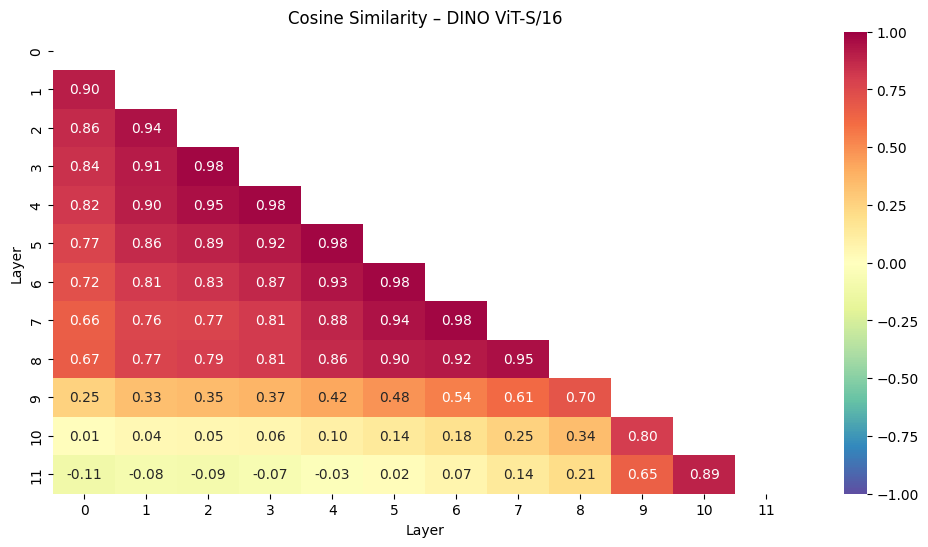

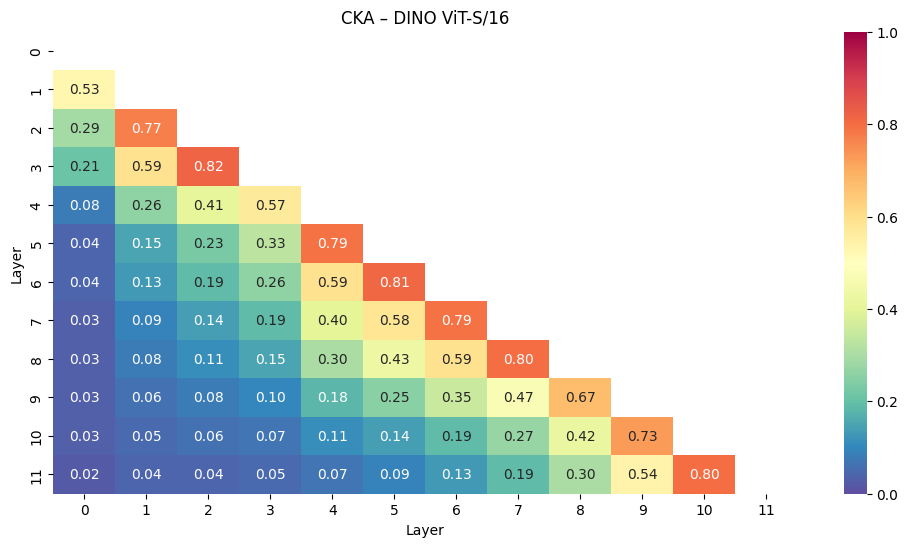

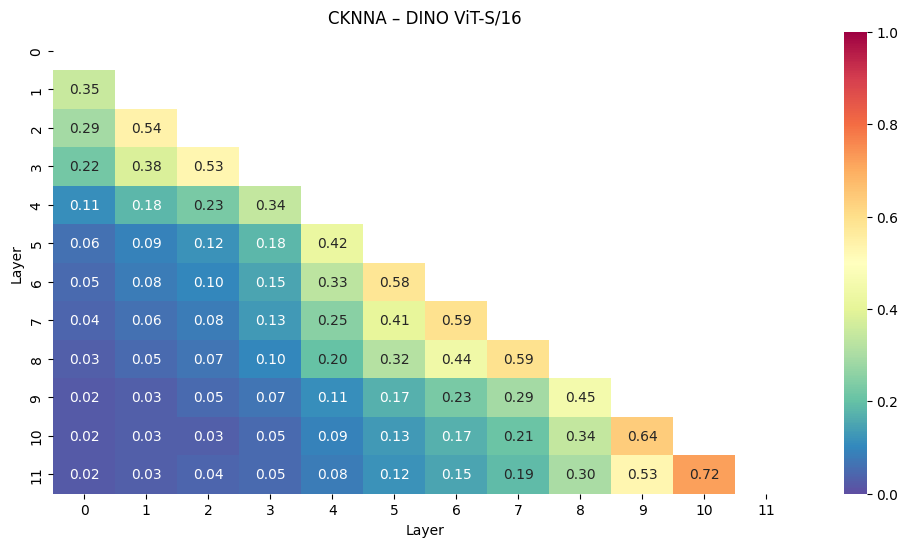


----- DINO ViT-B/8 -----


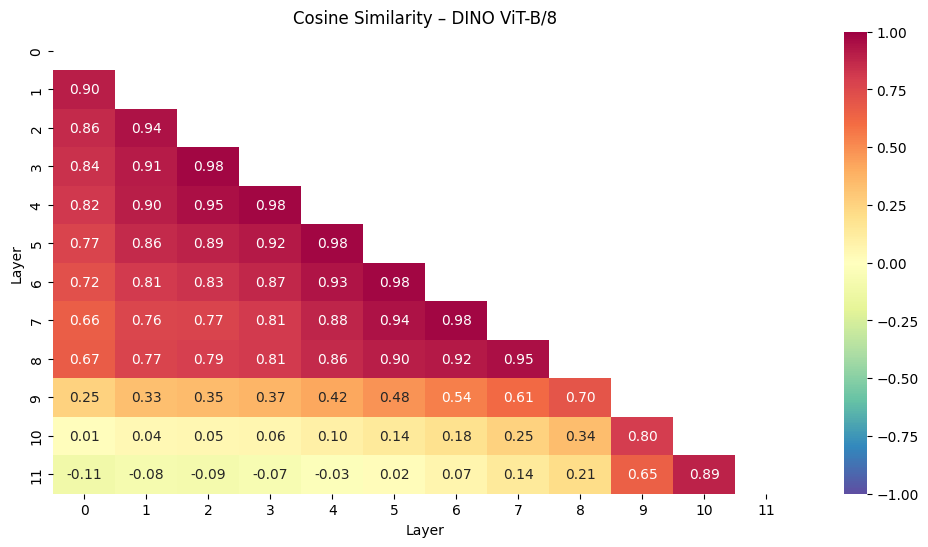

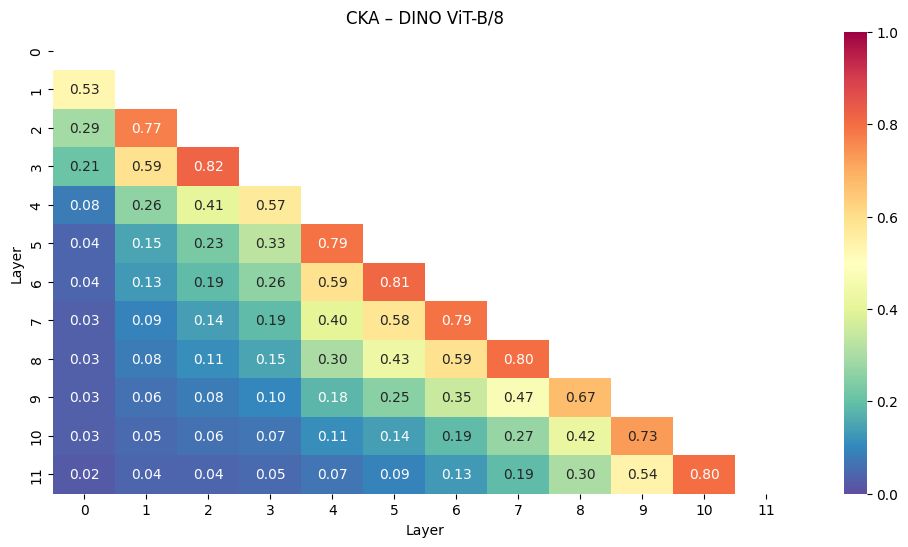

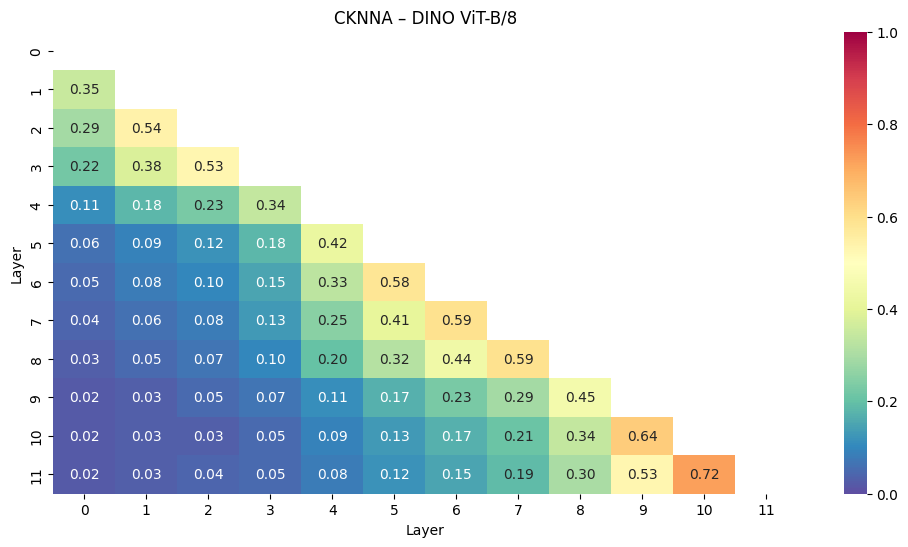

In [195]:
for model in models.values():
    model.eval()

for model_name, model in models.items():
    print(f"\n----- {model_name} -----")
    
    all_logits = collect_logits_from_batches(vits16, train_loader, max_batches=None)
    num_layers = len(all_logits[0])
    combined_logits = []

    for i in range(num_layers):
        layer_logits = [batch[i] for batch in all_logits]
        combined = torch.cat(layer_logits, dim=0)
        combined_logits.append(combined)

    cos_matrix = compute_cosine_similarity_matrix(combined_logits)
    cka_matrix = compute_cka_matrix(combined_logits)
    cknna_matrix = compute_cknna_matrix(combined_logits)

    plot_similarity_matrix(cos_matrix, title=f"Cosine Similarity – {model_name}")
    plot_similarity_matrix(cka_matrix, title=f"CKA – {model_name}", vmin=0)
    plot_similarity_matrix(cknna_matrix, title=f"CKNNA – {model_name}", vmin=0)

In [ ]:
'''
Przypomnijcie mi, że trzeb te moje złote myśli usunąć przed oddaniem projektu!

To w skrócie co jest zrobione:
Ładuje modele i dane i dla tej jednej wybranej klasy, liczę trzy różne miary, pomiędzy logitami z każdej warstwy,
te heatmapy interprtuje się następująco, kafelek (1, 4) to jest miara podobieństwa pomiędzy warstwą 1 a warstwą 4,
w opisach przed każdą funkcją dodałam interpretacje tych miar.
Osie kolorów rozciągają się od min do max dla danej miary czyli dla cosine similarity od -1 do 1, dla pozostałych
od 0 do 1, nie wiem czy to dobrze, ale według mnie tak się sensowniej intepretuje (możemy to zmienić te heatmapy
generowały sie jakiś 6 min).
Generalnie nie wiem czy te heatmapy to najlepszy możliwy sposób na wizualizację, jakbyście miały jakiś inny pomysł 
jak to pokazać to dawajcie znać

Jakby coś się nie zgadzało Wam w tym co zrobiłam to piszcie proszę!!!

Poniżej to co wydaje mi się, że trzeba dalej zrobić: 

TO DO:
Spisać wnioski z powyższych wykresów -> wytypować warstwy do ewentualnego pominięcia

Linear Probing Experiment ->
Train a linear classifier on frozen representations
Compare classification accuracy between: Full model vs Modified model with skipped layers
Discuss which layers carry redundant information

'''